In [1]:
!pip install pandas

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('/content/sample_orders.csv')

In [4]:
data

,Date,OrderID,Order Category,Order Value,Number of Items,Shipping Method,Discount %
0,2023-12-03,1161,Clothing,133.98,7,standard,14
1,2023-12-03,7386,Clothing,14.42,4,standard,8
2,2023-12-03,8346,Pet Supplies,15.15,1,priority,2
3,2023-12-04,4064,Clothing,112.18,7,standard,14
4,2023-12-04,6426,Clothing,173.48,10,standard,20
...,...,...,...,...,...,...,...
545,2024-03-01,5776,Electronics,133.66,10,standard,20
546,2024-03-01,6699,Clothing,100.17,6,priority,12
547,2024-03-02,1297,Pet Supplies,189.02,9,standard,18
548,2024-03-02,9980,Clothing,66.34,3,priority,6


In [5]:
data['Date'] = pd.to_datetime(data['Date'])

In [6]:
data

,Date,OrderID,Order Category,Order Value,Number of Items,Shipping Method,Discount %
0,2023-12-03,1161,Clothing,133.98,7,standard,14
1,2023-12-03,7386,Clothing,14.42,4,standard,8
2,2023-12-03,8346,Pet Supplies,15.15,1,priority,2
3,2023-12-04,4064,Clothing,112.18,7,standard,14
4,2023-12-04,6426,Clothing,173.48,10,standard,20
...,...,...,...,...,...,...,...
545,2024-03-01,5776,Electronics,133.66,10,standard,20
546,2024-03-01,6699,Clothing,100.17,6,priority,12
547,2024-03-02,1297,Pet Supplies,189.02,9,standard,18
548,2024-03-02,9980,Clothing,66.34,3,priority,6


In [7]:
sum_by_day = data.groupby('Date')['Order Value'].sum()

In [8]:
sum_by_day

Date
2023-12-03    163.55
2023-12-04    543.09
2023-12-05     95.66
2023-12-06    528.04
2023-12-07    666.79
               ...  
2024-02-27    641.08
2024-02-28    451.48
2024-02-29    826.20
2024-03-01    761.32
2024-03-02    446.14
Name: Order Value, Length: 91, dtype: float64

In [9]:
electronics_data = data[data['Order Category'] == "Electronics"]

In [10]:
electronics_daily = electronics_data.groupby('Date')['Order Value'].sum()

In [11]:
electronics_daily

Date
2023-12-04     41.09
2023-12-05     14.64
2023-12-06    196.14
2023-12-07    337.62
2023-12-10     80.08
               ...  
2024-02-26     95.69
2024-02-27     51.54
2024-02-28    121.90
2024-02-29    329.36
2024-03-01    622.19
Name: Order Value, Length: 81, dtype: float64

In [12]:
pet_data = data[data['Order Category'] == "Pet Supplies"]
daily_pets = pet_data.groupby('Date')['Order Value'].sum()

clothing_data = data[data['Order Category'] == "Clothing"]
daily_clothing = clothing_data.groupby('Date')['Order Value'].sum()


In [13]:
'''sum_by_day = data.groupby('Date')['Order Value'].sum()'''

sum_by_day.index

DatetimeIndex(['2023-12-03', '2023-12-04', '2023-12-05', '2023-12-06',
               '2023-12-07', '2023-12-08', '2023-12-09', '2023-12-10',
               '2023-12-11', '2023-12-12', '2023-12-13', '2023-12-14',
               '2023-12-15', '2023-12-16', '2023-12-17', '2023-12-18',
               '2023-12-19', '2023-12-20', '2023-12-21', '2023-12-22',
               '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26',
               '2023-12-27', '2023-12-28', '2023-12-29', '2023-12-30',
               '2023-12-31', '2024-01-01', '2024-01-02', '2024-01-03',
               '2024-01-04', '2024-01-05', '2024-01-06', '2024-01-07',
               '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11',
               '2024-01-12', '2024-01-13', '2024-01-14', '2024-01-15',
               '2024-01-16', '2024-01-17', '2024-01-18', '2024-01-19',
               '2024-01-20', '2024-01-21', '2024-01-22', '2024-01-23',
               '2024-01-24', '2024-01-25', '2024-01-26', '2024-01-27',
      

In [14]:
import matplotlib.pyplot as plt

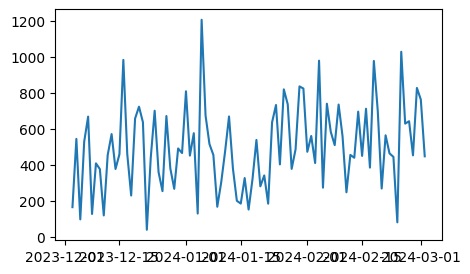

In [15]:
plt.figure(figsize=(5,3))
plt.plot(sum_by_day.index, sum_by_day.values)
plt.show()

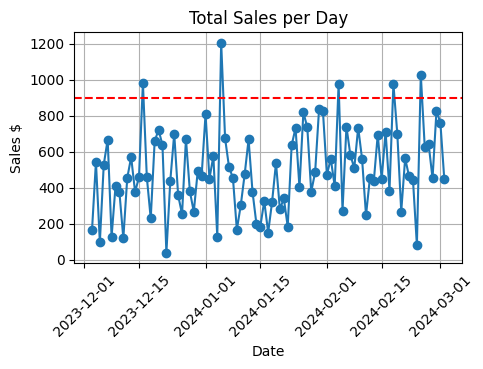

In [16]:
target = 900

plt.figure(figsize=(5,3))
plt.plot(sum_by_day.index, sum_by_day.values, marker='o', linestyle='-')
plt.title('Total Sales per Day')
plt.xlabel('Date')
plt.ylabel('Sales $')
plt.grid(True)
plt.xticks(rotation=45)
plt.axhline(y=target, color='r', linestyle='--', label='tgt')
plt.show()

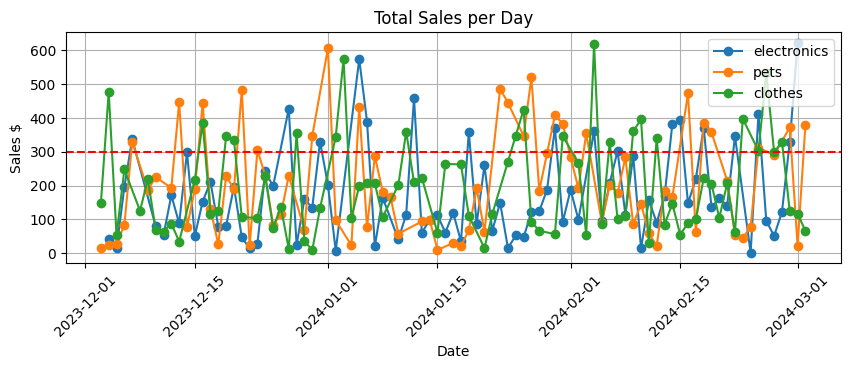

In [17]:
target = 300

plt.figure(figsize=(10,3))
plt.plot(electronics_daily.index, electronics_daily.values, marker='o', linestyle='-', label='electronics')
plt.plot(daily_pets.index, daily_pets.values, marker='o', linestyle='-', label='pets')
plt.plot(daily_clothing.index, daily_clothing.values, marker='o', linestyle='-', label='clothes')

plt.title('Total Sales per Day')
plt.xlabel('Date')
plt.ylabel('Sales $')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.axhline(y=target, color='r', linestyle='--', label='tgt')
plt.show()

In [18]:
sum_by_category = data.groupby('Order Category')['Order Value'].sum()


In [19]:
sum_by_category

Order Category
Clothing        15565.75
Electronics     14080.18
Pet Supplies    15576.13
Name: Order Value, dtype: float64

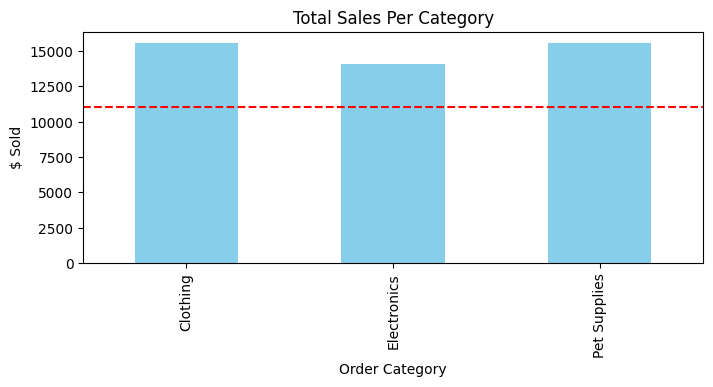

In [20]:
target = 11000

plt.figure(figsize=(8,3))
sum_by_category.plot(kind='bar', color='skyblue')
plt.axhline(y=target, color='r', linestyle='--')
plt.title('Total Sales Per Category')
plt.ylabel('$ Sold')
plt.show()

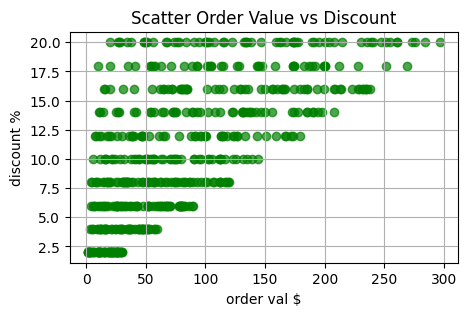

In [21]:
plt.figure(figsize=(5,3))
plt.scatter(data['Order Value'], data['Discount %'], color='green', alpha=0.7)
plt.title('Scatter Order Value vs Discount')
plt.ylabel('discount %')
plt.xlabel('order val $')
plt.grid(True)
plt.show()

In [22]:
!pip install seaborn
import seaborn as sns

In [23]:
sum_by_day = sum_by_day.reset_index()

In [24]:
sum_by_day

,Date,Order Value
0,2023-12-03,163.55
1,2023-12-04,543.09
2,2023-12-05,95.66
3,2023-12-06,528.04
4,2023-12-07,666.79
...,...,...
86,2024-02-27,641.08
87,2024-02-28,451.48
88,2024-02-29,826.20
89,2024-03-01,761.32


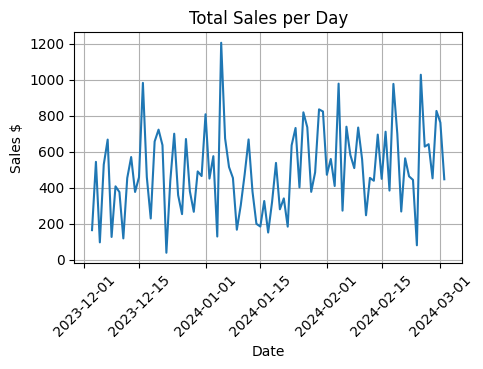

In [25]:
plt.figure(figsize=(5,3))
sns.lineplot(data=sum_by_day, x='Date', y='Order Value')
plt.title('Total Sales per Day')
plt.xlabel('Date')
plt.ylabel('Sales $')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

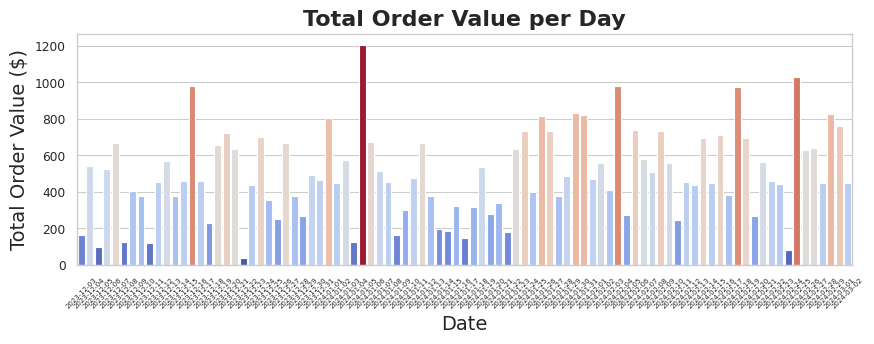

In [26]:
sns.set_theme(style='whitegrid', context="paper")
plt.figure(figsize=(10,3))
sns.barplot(data=sum_by_day, x='Date', y='Order Value', hue="Order Value", palette="coolwarm").legend().set_visible(False)
plt.xticks(rotation=45, fontsize=5)

plt.title('Total Order Value per Day', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Order Value ($)', fontsize=14)
plt.show()

In [27]:
plt.figure(figsize=(8,3))

<Figure size 800x300 with 0 Axes>

<Figure size 800x300 with 0 Axes>

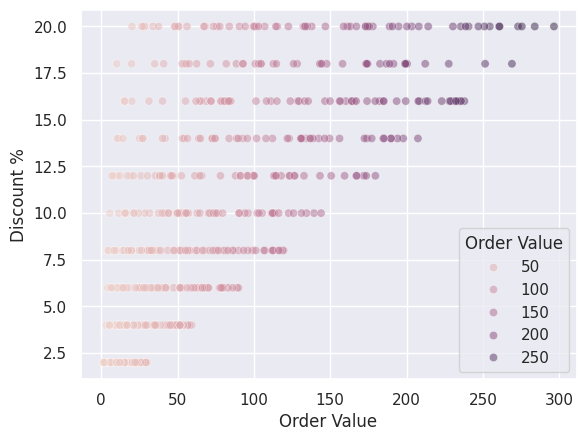

In [28]:
sns.set_theme(style='darkgrid')
sns.scatterplot(data=data, x='Order Value', y='Discount %', hue='Order Value', alpha=0.5)
plt.show()

In [29]:
!pip install plotly.express

In [30]:
import plotly.express as px

In [31]:
fig = px.line(sum_by_day, x='Date', y='Order Value', title='Sales Per Day')
target = 700
fig.add_hline(y=target, line_dash="dot", line_color="red")
fig.show()

In [32]:
electronics_daily = electronics_daily.reset_index()
daily_pets = daily_pets.reset_index()
daily_clothing = daily_clothing.reset_index()

In [33]:
electronics_daily

,Date,Order Value
0,2023-12-04,41.09
1,2023-12-05,14.64
2,2023-12-06,196.14
3,2023-12-07,337.62
4,2023-12-10,80.08
...,...,...
76,2024-02-26,95.69
77,2024-02-27,51.54
78,2024-02-28,121.90
79,2024-02-29,329.36


In [34]:
fig = px.line(electronics_daily, x='Date', y='Order Value')
fig.add_scatter(x=daily_pets['Date'], y=daily_pets['Order Value'], mode='lines', name='PETS')
fig.add_scatter(x=daily_clothing['Date'], y=daily_clothing['Order Value'], mode='lines', name = 'CLOTHES')

target = 300
fig.add_hline(y=target, line_dash="dot", line_color="red")
fig.show()

In [35]:
sum_by_category = sum_by_category.reset_index()

In [36]:
sum_by_category

,Order Category,Order Value
0,Clothing,15565.75
1,Electronics,14080.18
2,Pet Supplies,15576.13


In [37]:
fig = px.bar(sum_by_category, x='Order Category', y='Order Value', width=800, height=300,
             color='Order Value', color_continuous_scale='Viridis')

target = 13000
fig.add_hline(y=target, line_dash="dot", line_color = 'red')
fig.show()

In [38]:
fig = px.scatter(data, x='Order Value', y='Discount %', color='Order Value', opacity=0.5, height=300,
                 title="Sales Value vs Pct Discount")

fig.show()

# EXERCISE 1: AVERAGE OF DISCOUNT % OVER TIME IN MATPLOTLIB

You'll need to aggregate some data and plot it as a line chart in Matplot Lib. Be sure to add chart titles, X-Axis labels and Y-Axis labels:

avg_discount = data.groupby('Date')['Discount %'].mean()



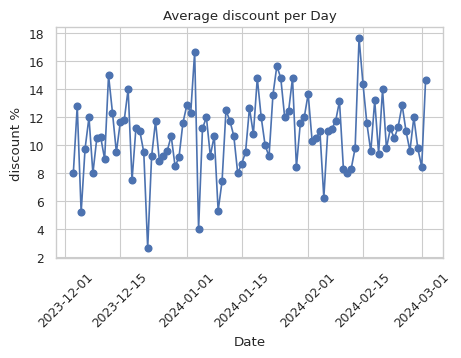

In [54]:
avg_discount = data.groupby('Date')['Discount %'].mean()

plt.figure(figsize=(5,3))
plt.plot(avg_discount.index, avg_discount.values, marker='o', linestyle='-')
plt.title('Average discount per Day')
plt.xlabel('Date')
plt.ylabel('discount %')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# EXERCISE 2: COUNT ORDERS PER CATEGORY IN SEABORN

You'll need to aggregate some data & then create a bar chart in Seaborn

orders_per_category = data.groupby('Order Category').count().reset_index()


Be sure to add a chart title, X-Axis label and Y-Axis Label

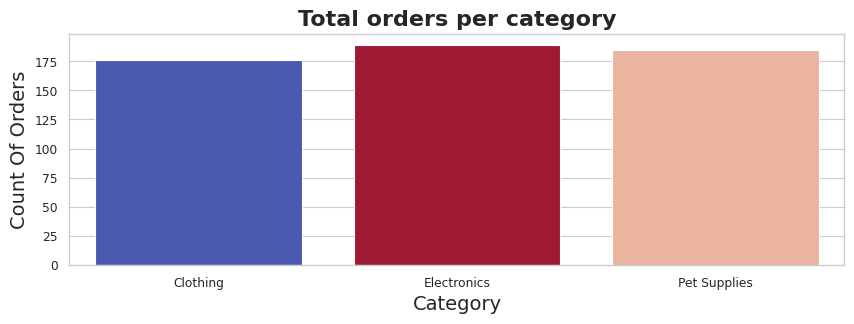

In [52]:
orders_per_category = data.groupby('Order Category').count().reset_index()


sns.set_theme(style='whitegrid', context="paper")

plt.figure(figsize=(10,3))
sns.barplot(data=orders_per_category, x='Order Category', y='OrderID', hue="OrderID", palette="coolwarm").legend().set_visible(False)

plt.title('Total orders per category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=14)
plt.ylabel('Count Of Orders', fontsize=14)
plt.show()

# CREATE A LINE CHART OF ONLY PET SALES IN PLOTLY

Using our daily_pets dataframe we used earlier, plot the order value for the Pet Supplies category over time. Be sure to add a chart title.

In [53]:
fig = px.line(daily_pets, x='Date', y='Order Value', title='Sales Per Day')
fig.show()